<a href="https://colab.research.google.com/github/5cxgp59c4b-glitch/stock-analysis/blob/main/%E6%A0%AA%E4%BE%A1%E5%88%86%E6%9E%90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

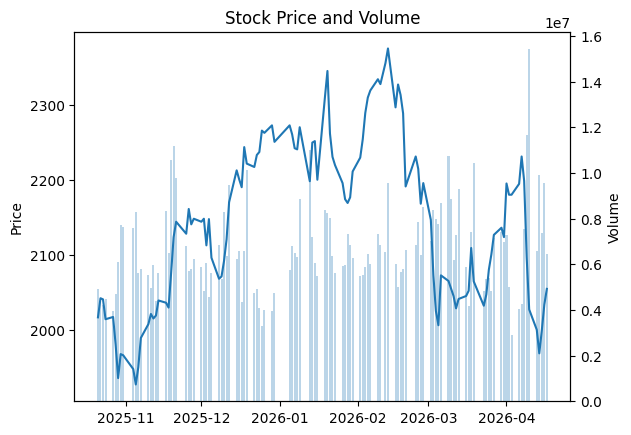

                 return  volume_change
return         1.000000       0.039895
volume_change  0.039895       1.000000


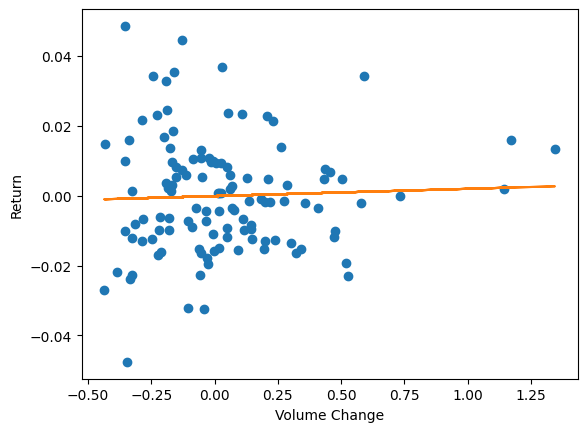

係数: [[0.00208429]]
切片: [-0.00010352]
R^2: 0.0015916124010922905
              return  volume_lag
return      1.000000    0.145332
volume_lag  0.145332    1.000000


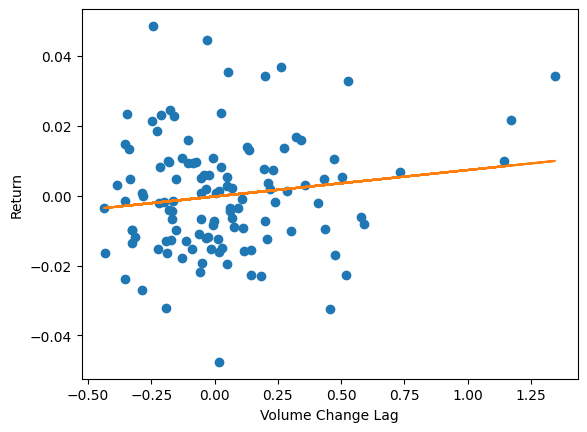

係数: [[0.00758421]]
切片: [-0.00021987]
R^2: 0.021121446229925733


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# データ取得
df = pd.read_excel("stock-sevenelven.xlsx")
df.columns = df.columns.str.strip()
df['date'] = pd.to_datetime(df['date'])

# 出来高の棒グラフと終値の折れ線グラフ
fig, ax1 = plt.subplots()

y1 = df['fixed-finish']
x1 = df['date']
y2 = df['volume']

ax1.plot(x1, y1, label='finish-price')
ax1.set_ylabel('Price')

ax2 = ax1.twinx()
ax2.bar(x1, y2, alpha=0.3, label='Volume')
ax2.set_ylabel('Volume')

plt.title('Stock Price and Volume')
plt.show()

# （変化率にすることで、時間におけるトレンドをある程度除去でき）
df['return'] = df['fixed-finish'].pct_change()
df['volume_change'] = df['volume'].pct_change()
df2 = df[['volume_change', 'return']].dropna()
x3=df2[['volume_change']]
y3=df2[['return']]

# 相関係数
print(df[['return', 'volume_change']].corr())

# 単回帰分析
model_lr = LinearRegression()
model_lr.fit(x3, y3)

plt.plot(x3, y3, 'o')
plt.plot(x3, model_lr.predict(x3), linestyle="solid")
plt.xlabel('Volume Change')
plt.ylabel('Return')
plt.show()
print("係数:", model_lr.coef_)
print("切片:", model_lr.intercept_)
print("R^2:", model_lr.score(x3, y3))


# ラグありで分析


df['volume_lag'] = df['volume_change'].shift(1)
df3 = df[['volume_lag', 'return']].dropna()
x4 = df3[['volume_lag']]
y4 = df3[['return']]
# 相関係数（ラグあり）
print(df[['return', 'volume_lag']].corr())

model_lr2 = LinearRegression()
model_lr2.fit(x4, y4)

plt.plot(x4, y4, 'o')
plt.plot(x4, model_lr2.predict(x4), linestyle="solid")
plt.xlabel('Volume Change Lag')
plt.ylabel('Return')
plt.show()
print("係数:", model_lr2.coef_)
print("切片:", model_lr2.intercept_)
print("R^2:", model_lr2.score(x4, y4))
